<a href="https://colab.research.google.com/github/prince969kr/sample_projec/blob/main/cleaned_logistic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('/content/logistics_preprocessing_dataset.csv')
df

,Order_ID,Origin,Destination,Product_Category,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level,Delivery_Status
0,ORD1001,Kolkata,Pune,Food,1023,45,14501.09,12.8,391,Delivered
1,ORD1002,Bengaluru,Jaipur,Electronics,24,11,18653.86,11.8,148,Delivered
2,ORD1003,Chennai,Lucknow,Electronics,1146,29,19296.27,1.9,365,In Transit
3,ORD1004,Bengaluru,Hyderabad,Food,1239,36,20658.36,1.6,342,In Transit
4,ORD1005,Bengaluru,Faridabad,Food,793,25,18733.19,9.7,268,Delivered
...,...,...,...,...,...,...,...,...,...,...
118,ORD1119,Delhi,Lucknow,Electronics,636,13,NaN,11.7,450,In Transit
119,ORD1120,Mumbai,Lucknow,Pharmaceuticals,1239,28,11754.00,2.2,106,In Transit
120,ORD1016,Mumbai,Hyderabad,Food,389,36,8405.82,10.8,177,Delivered
121,ORD1041,Kolkata,Hyderabad,Clothing,1232,49,9328.45,13.2,468,In Transit


In [4]:
df.head()

,Order_ID,Origin,Destination,Product_Category,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level,Delivery_Status
0,ORD1001,Kolkata,Pune,Food,1023,45,14501.09,12.8,391,Delivered
1,ORD1002,Bengaluru,Jaipur,Electronics,24,11,18653.86,11.8,148,Delivered
2,ORD1003,Chennai,Lucknow,Electronics,1146,29,19296.27,1.9,365,In Transit
3,ORD1004,Bengaluru,Hyderabad,Food,1239,36,20658.36,1.6,342,In Transit
4,ORD1005,Bengaluru,Faridabad,Food,793,25,18733.19,9.7,268,Delivered


In [5]:
df.shape

(123, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            123 non-null    object 
 1   Origin              123 non-null    object 
 2   Destination         123 non-null    object 
 3   Product_Category    123 non-null    object 
 4   Distance_km         123 non-null    int64  
 5   Quantity            123 non-null    int64  
 6   Shipping_Cost       118 non-null    float64
 7   Delivery_Time_days  118 non-null    float64
 8   Inventory_Level     123 non-null    int64  
 9   Delivery_Status     123 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 9.7+ KB


In [7]:
df.describe()

,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level
count,123.000000,123.000000,118.000000,118.000000,123.000000
mean,810.154472,26.471545,14815.786949,8.772034,254.796748
std,398.814350,13.942696,15064.045434,7.091115,144.273133
min,24.000000,1.000000,834.960000,1.000000,10.000000
25%,511.500000,13.500000,7046.225000,4.675000,127.000000
50%,842.000000,25.000000,13016.655000,8.500000,274.000000
75%,1134.000000,38.000000,19003.062500,11.300000,386.500000
max,1490.000000,49.000000,120000.000000,60.000000,492.000000


In [8]:
df.isnull().sum()

,0
Order_ID,0
Origin,0
Destination,0
Product_Category,0
Distance_km,0
Quantity,0
Shipping_Cost,5
Delivery_Time_days,5
Inventory_Level,0
Delivery_Status,0


In [9]:
shipping_median = df['Shipping_Cost'].median()
shipping_median

13016.654999999999

In [10]:
delivery_median = df['Delivery_Time_days'].median()
delivery_median

8.5

In [11]:
df['Shipping_Cost'] = df['Shipping_Cost'].fillna(shipping_median)
df.sample(4)

,Order_ID,Origin,Destination,Product_Category,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level,Delivery_Status
52,ORD1053,Kolkata,Pune,Electronics,716,47,14738.48,2.9,358,Delivered
43,ORD1044,Mumbai,Faridabad,Furniture,600,41,1291.74,14.8,85,In Transit
112,ORD1113,Bengaluru,Jaipur,Electronics,795,10,13912.43,14.6,487,In Transit
9,ORD1010,Bengaluru,Lucknow,Food,66,9,2530.84,8.5,270,Delivered


In [12]:
df['Delivery_Time_days'] = df['Delivery_Time_days'].fillna(delivery_median)
df.sample(4)

,Order_ID,Origin,Destination,Product_Category,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level,Delivery_Status
103,ORD1104,Mumbai,Jaipur,Furniture,31,45,20223.59,14.7,400,Delayed
14,ORD1015,Kolkata,Hyderabad,Electronics,288,48,14122.12,8.5,22,Delayed
22,ORD1023,Kolkata,Jaipur,Pharmaceuticals,1389,32,4572.28,45.0,282,Delivered
30,ORD1031,Chennai,Faridabad,Food,653,41,23988.21,2.8,104,Delayed


In [13]:
df.isnull().sum()

,0
Order_ID,0
Origin,0
Destination,0
Product_Category,0
Distance_km,0
Quantity,0
Shipping_Cost,0
Delivery_Time_days,0
Inventory_Level,0
Delivery_Status,0


In [14]:
df.duplicated().sum()

np.int64(3)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df['Delivery_Status'].unique()

array(['Delivered', 'In Transit', 'delivered', 'Delayed', 'Delayed '],
      dtype=object)

In [17]:
df['Origin'].unique()

array(['Kolkata', 'Bengaluru', 'Chennai', 'Mumbai', 'Delhi', 'Delhi '],
      dtype=object)

In [18]:

df['Delivery_Status'] = df['Delivery_Status'].str.strip()
df['Origin'] = df['Origin'].str.strip()
df['Origin'].unique()

array(['Kolkata', 'Bengaluru', 'Chennai', 'Mumbai', 'Delhi'], dtype=object)

In [19]:
df['Delivery_Status'] = df['Delivery_Status'].str.title()
df['Delivery_Status'].unique()

array(['Delivered', 'In Transit', 'Delayed'], dtype=object)

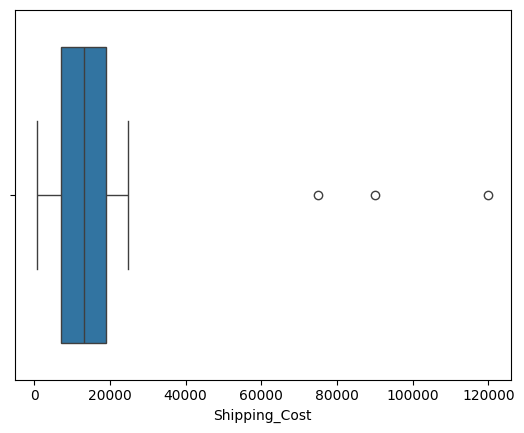

In [20]:
sns.boxplot(x=df['Shipping_Cost'])
plt.show()

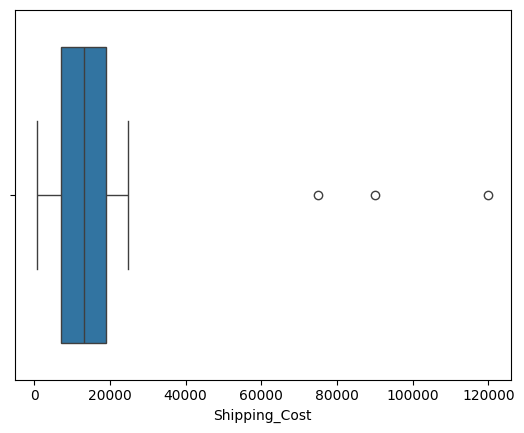

In [21]:
sns.boxplot(x=df['Shipping_Cost'])
plt.show()

In [22]:
Q1 = df['Shipping_Cost'].quantile(0.25)
Q3 = df['Shipping_Cost'].quantile(0.75)

In [23]:
IQR = Q3 - Q1

In [24]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [25]:
outliers = df[(df['Shipping_Cost'] < lower) |
              (df['Shipping_Cost'] > upper)]

print(outliers[['Order_ID', 'Shipping_Cost']])

   Order_ID  Shipping_Cost
10  ORD1011        75000.0
45  ORD1046        90000.0
88  ORD1089       120000.0


In [26]:
Q1 = df['Delivery_Time_days'].quantile(0.25)
Q3 = df['Delivery_Time_days'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Delivery_Time_days'] < lower) |
              (df['Delivery_Time_days'] > upper)]

print(outliers[['Order_ID', 'Delivery_Time_days']])

   Order_ID  Delivery_Time_days
22  ORD1023                45.0
76  ORD1077                60.0


In [27]:
Q1 = df['Shipping_Cost'].quantile(0.25)
Q3 = df['Shipping_Cost'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Shipping_Cost'] >= lower) &
        (df['Shipping_Cost'] <= upper)]

In [28]:
Q1 = df['Delivery_Time_days'].quantile(0.25)
Q3 = df['Delivery_Time_days'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Delivery_Time_days'] >= lower) &
        (df['Delivery_Time_days'] <= upper)]

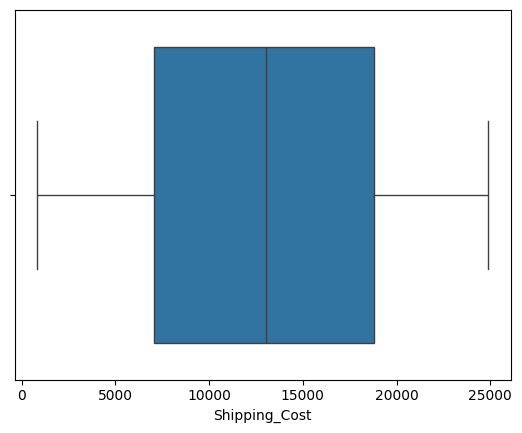

In [29]:
sns.boxplot(x=df['Shipping_Cost'])
plt.show()

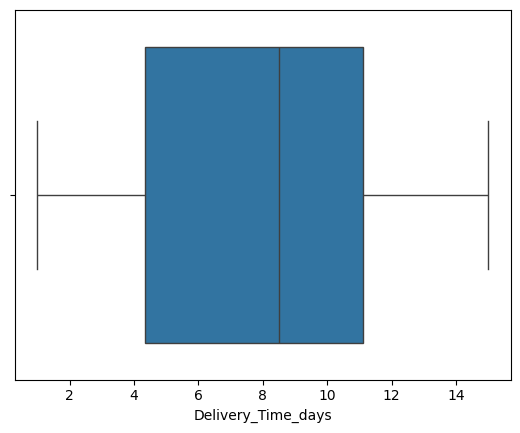

In [30]:
sns.boxplot(x=df['Delivery_Time_days'])
plt.show()

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
columns = ['Distance_km', 'Quantity', 'Shipping_Cost',
           'Delivery_Time_days', 'Inventory_Level']

df[columns] = scaler.fit_transform(df[columns])

In [32]:
df[columns].head()

,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level
0,0.681446,0.916667,0.567933,0.842857,0.790456
1,0.000000,0.208333,0.740513,0.771429,0.286307
2,0.765348,0.583333,0.767210,0.064286,0.736515
3,0.828786,0.729167,0.823816,0.042857,0.688797
4,0.524557,0.500000,0.743810,0.621429,0.535270


In [35]:
df.isnull().sum()

,0
Order_ID,0
Origin,0
Destination,0
Product_Category,0
Distance_km,0
Quantity,0
Shipping_Cost,0
Delivery_Time_days,0
Inventory_Level,0
Delivery_Status,0


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.shape

(115, 10)

In [38]:
df.head()

,Order_ID,Origin,Destination,Product_Category,Distance_km,Quantity,Shipping_Cost,Delivery_Time_days,Inventory_Level,Delivery_Status
0,ORD1001,Kolkata,Pune,Food,0.681446,0.916667,0.567933,0.842857,0.790456,Delivered
1,ORD1002,Bengaluru,Jaipur,Electronics,0.000000,0.208333,0.740513,0.771429,0.286307,Delivered
2,ORD1003,Chennai,Lucknow,Electronics,0.765348,0.583333,0.767210,0.064286,0.736515,In Transit
3,ORD1004,Bengaluru,Hyderabad,Food,0.828786,0.729167,0.823816,0.042857,0.688797,In Transit
4,ORD1005,Bengaluru,Faridabad,Food,0.524557,0.500000,0.743810,0.621429,0.535270,Delivered


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115 entries, 0 to 119
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            115 non-null    object 
 1   Origin              115 non-null    object 
 2   Destination         115 non-null    object 
 3   Product_Category    115 non-null    object 
 4   Distance_km         115 non-null    float64
 5   Quantity            115 non-null    float64
 6   Shipping_Cost       115 non-null    float64
 7   Delivery_Time_days  115 non-null    float64
 8   Inventory_Level     115 non-null    float64
 9   Delivery_Status     115 non-null    object 
dtypes: float64(5), object(5)
memory usage: 9.9+ KB


In [40]:
df.to_csv('cleaned_logistics_dataset.csv', index=False)